In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### MNIST dataset

In [2]:
# Function to one-hot encode the target variable into the 10 classes (0-9)
# Input shape: (N,),    Output: (N, 10)
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

In [3]:
# Loading the MNIST dataset
train_data=pd.read_csv(r"./mnist_train.csv")
test_data=pd.read_csv(r"./mnist_test.csv")

# Preprocessing the data
train_data=train_data.to_numpy()    # train_data shape: (60000, 785)
test_data=test_data.to_numpy()      # test_data shape: (10000, 785)

X_train=train_data[:,1:]            # X_train shape: (60000, 784)
y_train=train_data[:,0]             # y_train shape: (60000,)
X_test=test_data[:,1:]              # X_test shape: (10000, 784)
y_test=test_data[:,0]               # y_test shape: (10000,)

X_train = X_train / 255.0           # Normalizing the data
X_test = X_test / 255.0

one_hot_y_train = one_hot(y_train)  # one_hot_y_train shape: (60000, 10)
one_hot_y_test = one_hot(y_test)    # one_hot_y_test shape: (10000, 10)

#### Training on the other Boolean functions

In [4]:
X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
Y_xor = np.array([
    [0],
    [1],
    [1],
    [0]
])

In [5]:
def generate_perm(n):
    all_perm = []
    for mask in range(1<<n):
        sequence = [(mask >> i) & 1 for i in range(n-1,-1,-1)]
        all_perm.append(sequence)
    return all_perm
    

In [6]:
def is_palindrome(seq):
    return seq == seq[::-1]

def check_palindrome(X):
    return [is_palindrome(seq) for seq in X]

X_palindrome_4 = generate_perm(4)
Y_palindrome_4 = check_palindrome(X_palindrome_4)
Y_palindrome_4 = np.array(Y_palindrome_4).reshape(-1,1).astype(int)
X_palindrome_4 = np.array(X_palindrome_4)

In [7]:
X_palindrome_5 = generate_perm(5)
Y_palindrome_5 = check_palindrome(X_palindrome_5)
Y_palindrome_5 = np.array(Y_palindrome_5).reshape(-1,1).astype(int)
X_palindrome_5 = np.array(X_palindrome_5)

In [8]:
def is_parity(seq):
    n_ones = 0
    for bit in seq:
        if bit == 1:
            n_ones+=1
    #print(seq, n_zeros, n_ones)
    if n_ones %2==0:
        return 1
    else:
        return 0

def parity(X):
    return [is_parity(seq) for seq in X]

X_parity_4 = generate_perm(4)
Y_parity_4 = parity(X_parity_4)
Y_parity_4 = np.array(Y_parity_4).reshape(-1,1).astype(int)
X_parity_4 = np.array(X_parity_4)
X_parity_4, Y_parity_4

(array([[0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 1, 1, 1],
        [1, 0, 0, 0],
        [1, 0, 0, 1],
        [1, 0, 1, 0],
        [1, 0, 1, 1],
        [1, 1, 0, 0],
        [1, 1, 0, 1],
        [1, 1, 1, 0],
        [1, 1, 1, 1]]),
 array([[1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [1],
        [1],
        [0],
        [1],
        [0],
        [0],
        [1]]))

In [9]:
X_parity_5 = generate_perm(5)
Y_parity_5 = parity(X_parity_5)
Y_parity_5 = np.array(Y_parity_5).reshape(-1,1).astype(int)
X_parity_5 = np.array(X_parity_5)
X_parity_5, Y_parity_5

(array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 1],
        [0, 0, 1, 0, 0],
        [0, 0, 1, 0, 1],
        [0, 0, 1, 1, 0],
        [0, 0, 1, 1, 1],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 1],
        [0, 1, 0, 1, 0],
        [0, 1, 0, 1, 1],
        [0, 1, 1, 0, 0],
        [0, 1, 1, 0, 1],
        [0, 1, 1, 1, 0],
        [0, 1, 1, 1, 1],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 1],
        [1, 0, 0, 1, 0],
        [1, 0, 0, 1, 1],
        [1, 0, 1, 0, 0],
        [1, 0, 1, 0, 1],
        [1, 0, 1, 1, 0],
        [1, 0, 1, 1, 1],
        [1, 1, 0, 0, 0],
        [1, 1, 0, 0, 1],
        [1, 1, 0, 1, 0],
        [1, 1, 0, 1, 1],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 1],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]]),
 array([[1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [1],
        [1],
        [0],
        [1],
        [0],
        [0],
   

In [10]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def sigmoid_derivative(x):
    return x*(1-x) 


In [11]:
class FeedForwardNN:
    def __init__(self,input_size, hidden_layer_size,flag):
        self.w1 = np.random.rand(input_size,hidden_layer_size)
        self.w2 = np.random.rand(hidden_layer_size,1)
        self.b1=np.random.rand(1,hidden_layer_size)
        self.b2=np.random.rand(1,1)
        self.flag = flag
        
    def forward(self, X):
        z1 = np.dot(X,self.w1)+self.b1
        a1 = sigmoid(z1)
        z2= np.dot(a1,self.w2)+ self.b2
        return z1,a1,z2,sigmoid(z2)

    def tss_loss(self,y, y_pred):
        return np.sum((y-y_pred)**2)
    
    def ce_loss(self,y,y_pred):
        return -np.sum(y * np.log(y_pred + 1e-8))/y.shape[0]

    def backward(self,X,Y,Y_pred,learning_rate,z1,a1,z2):
        # dloss_dz = 2*(Y_pred-Y)*sigmoid_derivative(Y_pred)
        # dloss_dw = np.dot(X.T,dloss_dz)/X.shape[0]
        # dloss_db = np.sum(dloss_dz)/X.shape[0]

        # self.weights -= learning_rate*dloss_dw
        # self.bias -= learning_rate *dloss_db
        da2 = Y_pred - Y
        if self.flag ==1 :
            dz2 = 2*da2*sigmoid_derivative(Y_pred)
        else:
            dz2 = da2
        dw2 = np.dot(a1.T,dz2)/X.shape[0]
        db2 = np.sum(dz2,axis=0,keepdims=True)/X.shape[0]

        da1=np.dot(dz2,self.w2.T)
        dz1=da1* sigmoid_derivative(a1)
        dw1=np.dot(X.T,dz1)/X.shape[0]
        db1 = np.sum(dz1,axis=0, keepdims=True)/X.shape[0]

        self.w1-= learning_rate*dw1
        self.b1-=learning_rate*db1
        self.w2-=learning_rate*dw2
        self.b2-=learning_rate*db2
         



    # def predict(self,X):
    #     return [1 if self.forward(seq) > 0.5 else 0 for seq in X]
   

In [12]:
def train(X,Y,iterations=20000,learning_rate=0.2):
        input_size = X.shape[1]
        ffnn1 = FeedForwardNN(input_size,hidden_layer_size=4,flag=1)
        tss_loss = []
        for i in range(iterations):
            z1,a1,z2,Y_pred = ffnn1.forward(X)
            loss = ffnn1.tss_loss(Y,Y_pred)
            tss_loss.append(loss)
            ffnn1.backward(X,Y,Y_pred,learning_rate,z1,a1,z2)

        _,_,_,final_pred = ffnn1.forward(X)

        ffnn2 = FeedForwardNN(input_size,hidden_layer_size=4,flag=0)
        ce_loss = []
        for i in range(iterations):
            z1,a1,z2,Y_pred = ffnn2.forward(X)
            loss = ffnn2.ce_loss(Y,Y_pred)
            ce_loss.append(loss)
            ffnn2.backward(X,Y,Y_pred,learning_rate,z1,a1,z2)

        _,_,_,final_pred = ffnn2.forward(X)
      #  print(final_pred,tss_loss)
        return final_pred,tss_loss, ce_loss
        

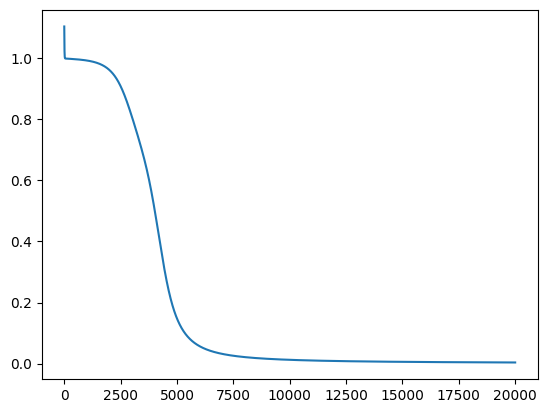

In [13]:
pred,tss_loss,ce_loss = train(X_xor,Y_xor)
plt.plot(tss_loss)
plt.show()


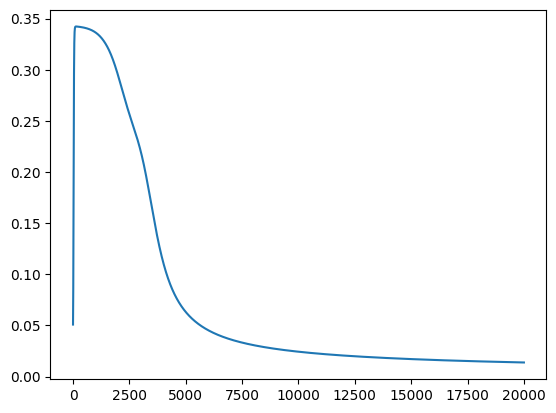

In [14]:
plt.plot(ce_loss)
plt.show()

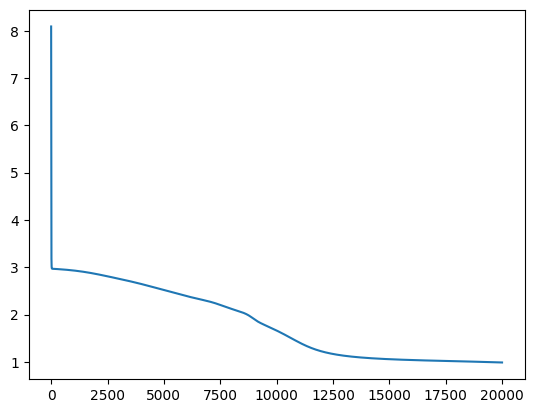

In [20]:
pred,tss_loss,ce_loss = train(X_palindrome_4,Y_palindrome_4, iterations=20000,learning_rate=0.3)
plt.plot(tss_loss)
plt.show()

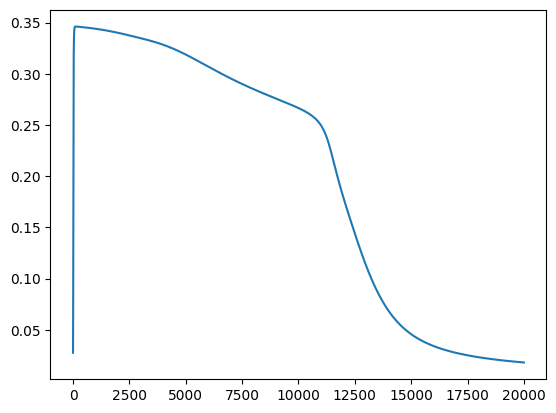

In [21]:
Y_palindrome_4
plt.plot(ce_loss)
plt.show()

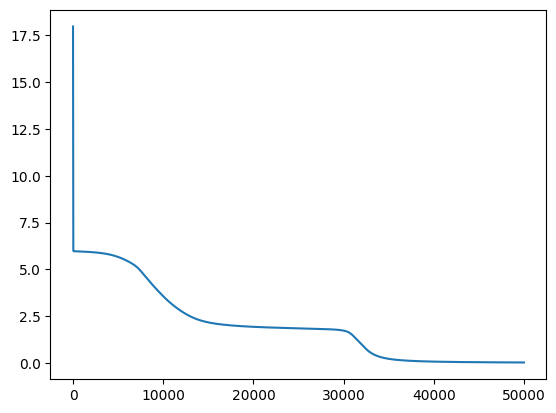

In [22]:
pred,tss_loss,ce_loss = train(X_palindrome_5,Y_palindrome_5,iterations=50000)
plt.plot(tss_loss)
plt.show()

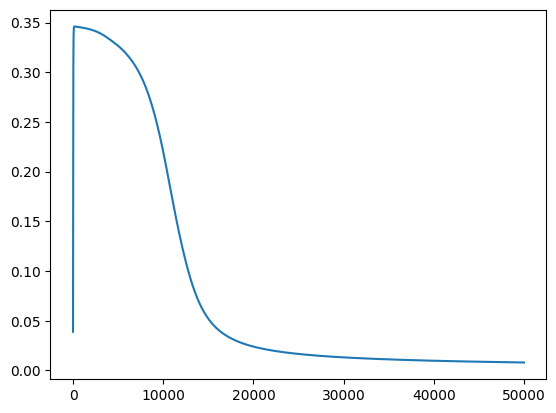

In [24]:
Y_palindrome_5
plt.plot(ce_loss)
plt.show()

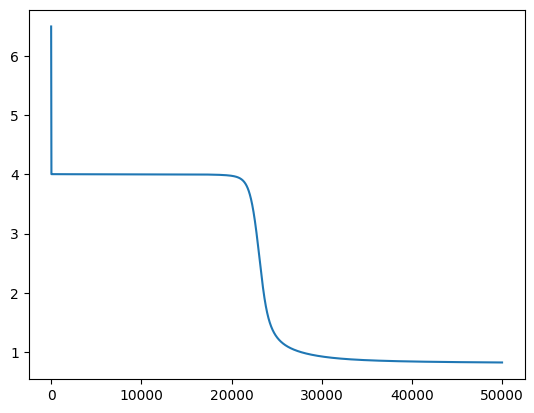

In [25]:
pred,tss_loss,ce_loss = train(X_parity_4,Y_parity_4,iterations=50000,learning_rate=.4)
plt.plot(tss_loss)
plt.show()

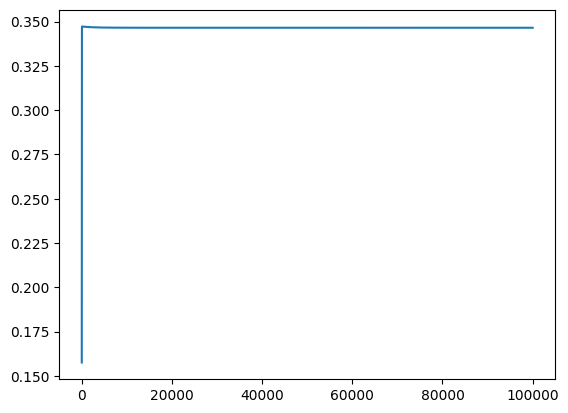

In [26]:
pred,tss_loss,ce_loss = train(X_parity_5,Y_parity_5,iterations=100000,learning_rate=.3)
plt.plot(ce_loss)
plt.show()

# MNIST 

In [27]:
def softmax(Z):
    exp_z = np.exp(Z-np.max(Z,axis=1,keepdims=True))
    return exp_z/np.sum(exp_z, axis=1, keepdims=True)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

In [30]:
class NN:
    def __init__(self,input_size, hidden_layer_size,output_size=10, flag=1):
        self.w1 = np.random.randn(input_size,hidden_layer_size)
        self.w2 = np.random.randn(hidden_layer_size,output_size)
        self.b1=np.random.rand(1,hidden_layer_size)
        self.b2=np.random.rand(1,output_size)
        self.flag = flag
        
      
    def forward(self, X):
        z1 = np.dot(X,self.w1)+self.b1
        a1 = relu(z1)
        z2= np.dot(a1,self.w2)+ self.b2
        return z1,a1,z2,softmax(z2)

    def tss_loss(self,y, y_pred):
        return np.sum((y-y_pred)**2)
    
    def cross_entropy_loss(self,y,y_pred):
        return -np.sum(y * np.log(y_pred + 1e-8))/y.shape[0]

    def backward(self,X,Y,Y_pred,learning_rate,z1,a1,z2):
        
        da2 = Y_pred - Y
        if self.flag ==1 :
            dz2 = 2*da2*relu_derivative(Y_pred)
        else:
            dz2 = da2
        dw2 = np.dot(a1.T,dz2)/X.shape[0]
        db2 = np.sum(dz2,axis=0,keepdims=True)/X.shape[0]

        da1=np.dot(dz2,self.w2.T)
        dz1=da1* relu_derivative(a1)
        dw1=np.dot(X.T,dz1)/X.shape[0]
        db1 = np.sum(dz1,axis=0, keepdims=True)/X.shape[0]

        self.w1-= learning_rate*dw1
        self.b1-= learning_rate*db1
        self.w2-= learning_rate*dw2
        self.b2-= learning_rate*db2
         



    # def predict(self,X):
    #     return [1 if self.forward(seq) > 0.5 else 0 for seq in X]
   

In [33]:
def train_mnist(X,Y,X_test, Y_test,iterations=100,learning_rate=.1):
    input_size = X.shape[1]
    nn = NN(input_size,hidden_layer_size=128,flag=1)
    tss = []
    print(iterations)
    for i in range(iterations):
        z1,a1,z2,Y_pred = nn.forward(X)
        loss = nn.tss_loss(Y,Y_pred)
        tss.append(loss)
        nn.backward(X,Y,Y_pred,learning_rate,z1,a1,z2)
        if i%10==0:
                print(f"Epoch number: {i} | Loss = {loss}")

    # _,_,_,final_pred = nn.forward(X_test)
    
    # predictions = np.argmax(final_pred,axis=1)
    # print(predictions[:10],Y_test[:10])
    # return np.mean(predictions==Y_test)
    _,_,_,A2=nn.forward(X_test)
    predictions=np.argmax(A2,axis=1)
    true_labels=np.argmax(one_hot_y_test,axis=1)
    print(f"TEST ACCURACY: {(np.mean(predictions == true_labels))*100}%")
    print(predictions[:10])

    nn2 = NN(input_size,hidden_layer_size=128,flag=0)
    ce_loss = []
    print(iterations)
    for i in range(iterations):
        z1,a1,z2,Y_pred = nn.forward(X)
        loss = nn.cross_entropy_loss(Y,Y_pred)
        ce_loss.append(loss)
        nn.backward(X,Y,Y_pred,learning_rate,z1,a1,z2)
        if i%10==0:
                print(f"Epoch number: {i} | Loss = {loss}")

    # _,_,_,final_pred = nn.forward(X_test)
    
    # predictions = np.argmax(final_pred,axis=1)
    # print(predictions[:10],Y_test[:10])
    # return np.mean(predictions==Y_test)
    _,_,_,A2=nn.forward(X_test)
    predictions=np.argmax(A2,axis=1)
    true_labels=np.argmax(one_hot_y_test,axis=1)
    print(f"TEST ACCURACY: {(np.mean(predictions == true_labels))*100}%")
    print(predictions[:10])
 
    return tss,ce_loss



In [ ]:
tss_loss, ce_loss = train_mnist(X_train,one_hot_y_train,X_test, one_hot_y_test)

100
Epoch number: 0 | Loss = 109139.21243475695
Epoch number: 10 | Loss = 42052.66582086268
Epoch number: 20 | Loss = 30993.002027378698
Epoch number: 30 | Loss = 26494.483663425934
Epoch number: 40 | Loss = 23939.43213257011
Epoch number: 50 | Loss = 22172.980524606344
Epoch number: 60 | Loss = 20857.986530799768
Epoch number: 70 | Loss = 19841.248186870806
Epoch number: 80 | Loss = 18984.82608765033
Epoch number: 90 | Loss = 18253.978268924617
TEST ACCURACY: 84.17999999999999%
[7 2 1 0 7 1 4 1 0 9]
100
Epoch number: 0 | Loss = 1.8992123345440592
Epoch number: 10 | Loss = 1.821785217311622
Epoch number: 20 | Loss = 1.7529286274103062
Epoch number: 30 | Loss = 1.6908889353813332
Epoch number: 40 | Loss = 1.6343298095984147
Epoch number: 50 | Loss = 1.582674862272069
Epoch number: 60 | Loss = 1.5352718105816894


In [1]:
y_test[:10]
plt.plot(tss_loss)
plt.show()

NameError: name 'y_test' is not defined

In [ ]:
plt.plot(ce_loss)
plt.show()